# Machine Learning Project: Speech Emotion Recognition System - PART A (BASELINE)

In this notebook (Part A), we will establish a baseline using 162 standard acoustic features (MFCCs, mel spectrograms, chroma features, zero-crossing rate and RMS energy) with with nine classical machine learning algorithms: Logistic Regression (LR), Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Naive Bayes (NB), Gaussian Mixture Model (GMM), Decision Tree (DT), Bagging, Random Forest (RF),  AdaBoost.

In Part B (Systematic Improvement) of the notebook, we will systematically improve upon this baseline through enhanced feature engineering (adding 48 features), advanced classification strategies (hierarchical classification & specialist classifiers for confused emotion pairs) and ensemble methods (stacking classifiers with optimized feature selection).

**COURSE:** 61.501 Production Ready ML – Sep 2025      

**TEAM:**  
Sagar Pratap Singh | 1010738  
Seow Chun Yong | 1000108  
Yang Qingwei | 1010737

**REQUIREMENTS:**  
numpy==2.3.5  
scipy==1.16.3  
pandas==2.3.3  
scikit-learn==1.7.2  
matplotlib==3.10.7  
seaborn==0.13.2  
librosa==0.11.0  
jupyterlab==4.5.0  

**INSTRUCTIONS TO RETRAIN THE MODELS IN ITS ENTIRETY (TAKES 3-4HRS TO RUN)**  
**NOTE:** Due to the number of experiments that you have to run, **each** notebook will take 3-4 hours to run.

1. git clone https://github.com/sagerstack/ml-speech-emotion-recognition.git
2. Download CREMA-D Dataset:
    - Navigate to https://drive.google.com/drive/folders/1tvWeyxZM0bvKVhogRD1yCnwnpgOScJet?usp=share_link
    - Download `AudioWAV` folder in its entirety, and place the folder in `notebooks\AudioWAV`.
    - Alternatively, you may download CREMA-D Dataset from : https://www.kaggle.com/datasets/ejlok1/cremad 
    - Ensure you unzip the audio files into `notebooks\AudioWAV` directory.
3. Install required python packages: `pip install -r requirements.txt`  
4. Open `PART A - Baseline Models.ipynb` or `PART B - Systematic Improvements.ipynb` in Jupyter Notebook.  
5. Run all cells in order (Kernel → Restart & Run All).  
6. Training results and plots will be displayed at the end.


## Import Libraries and Load CREMA-D Dataset

#### Crowd Sourced Emotional Multimodal Actors Dataset
CREMA-D is a data set of 7,442 original clips from 91 actors. These clips were from 48 male and 43 female actors between the ages of 20 and 74 coming from a variety of races and ethnicities (African America, Asian, Caucasian, Hispanic, and Unspecified). Actors spoke from a selection of 12 sentences. The sentences were presented using one of six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).

https://www.kaggle.com/datasets/ejlok1/cremad

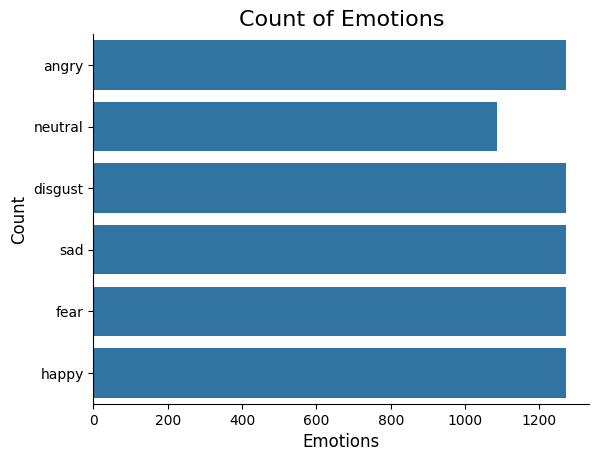

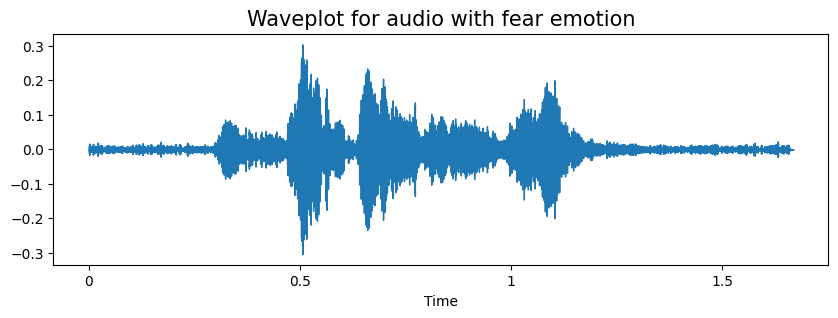

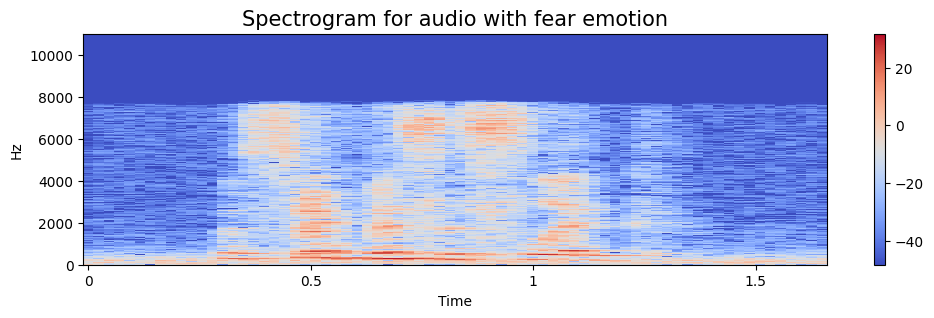

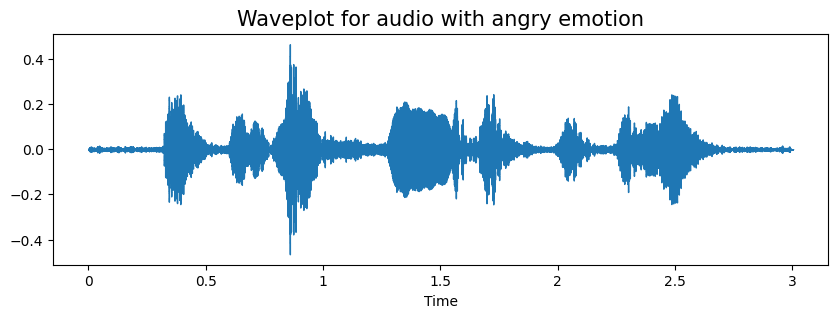

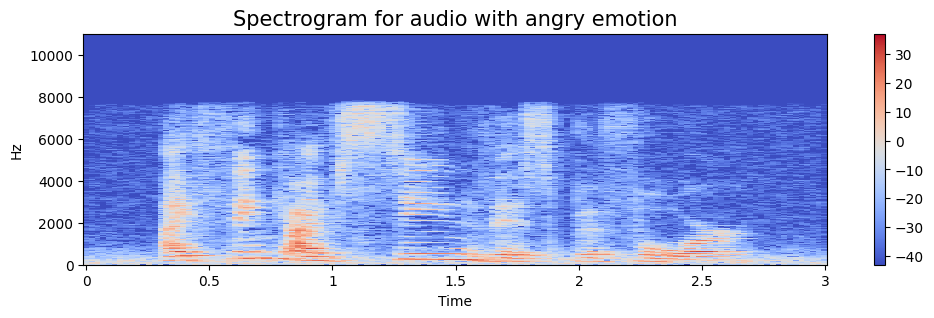

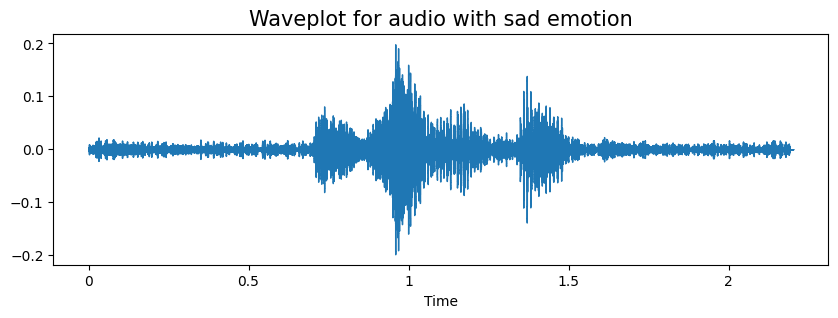

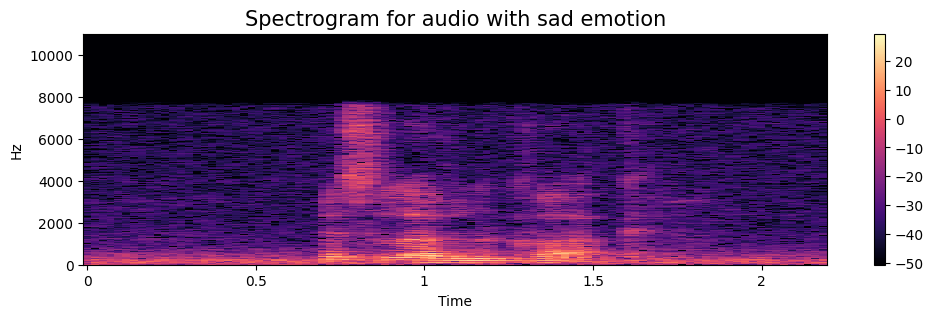

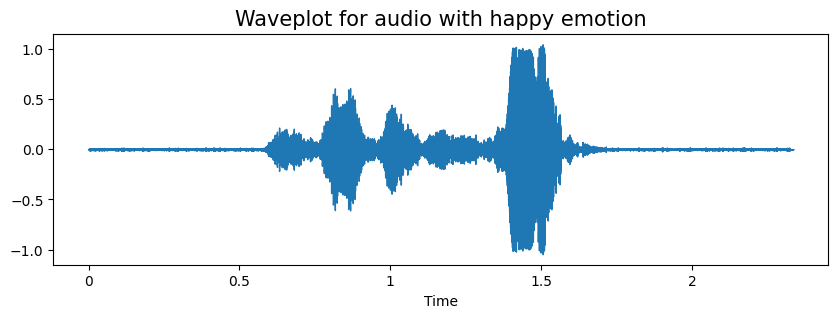

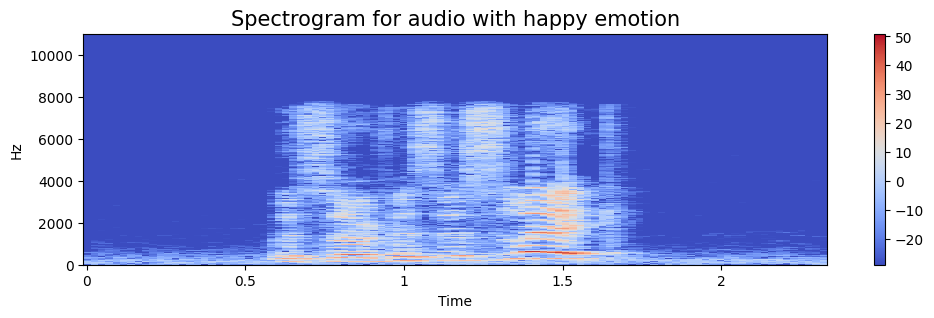

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython
import IPython.display as ipd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import Audio

Crema = "./AudioWAV/"
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df.head()

data_path = pd.concat([Crema_df], axis = 0) # Add future datasets here
data_path.to_csv("part_a_data_path.csv",index=False)
data_path.head()

plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    try:
        # librosa >= 0.10
        librosa.display.waveshow(data, sr=sr)
    except AttributeError:
        # fallback if waveshow is not available: simple time-domain plot
        times = np.arange(len(data)) / sr
        plt.plot(times, data)
        plt.xlabel('Time (s)')
    plt.show()

def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

emotion='fear'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

emotion='angry'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

emotion='sad'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

emotion='happy'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)




## Data Augmentation
To increase training data diversity and improve model robustness to real-world variations, we apply augmentation to grow the dataset. Each original clip is kept, plus two augmented variants, giving a 3x expansion:  
•	Variant 1 (Random Noise): Add random noise to simulate mic/background variability and misalignment.  
•	Variant 2 (Stretch/Pitch Shift): Shift pitch slightly to simulate more realistic speaker pitch variation.

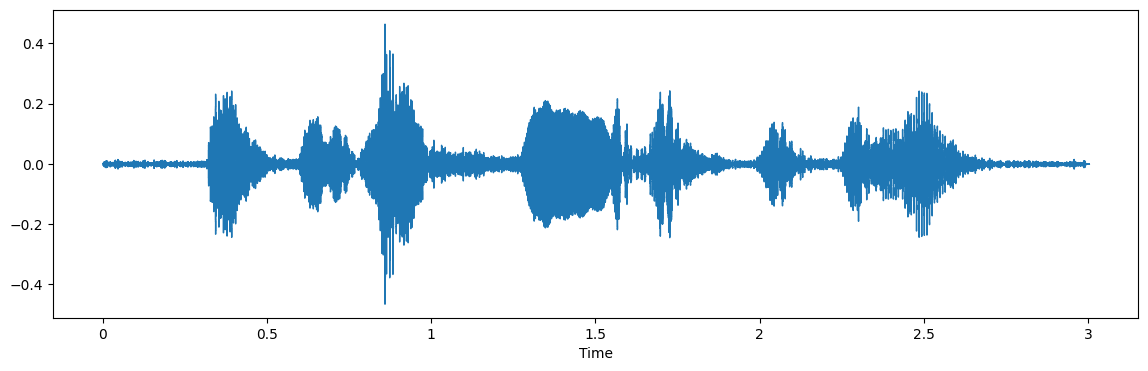

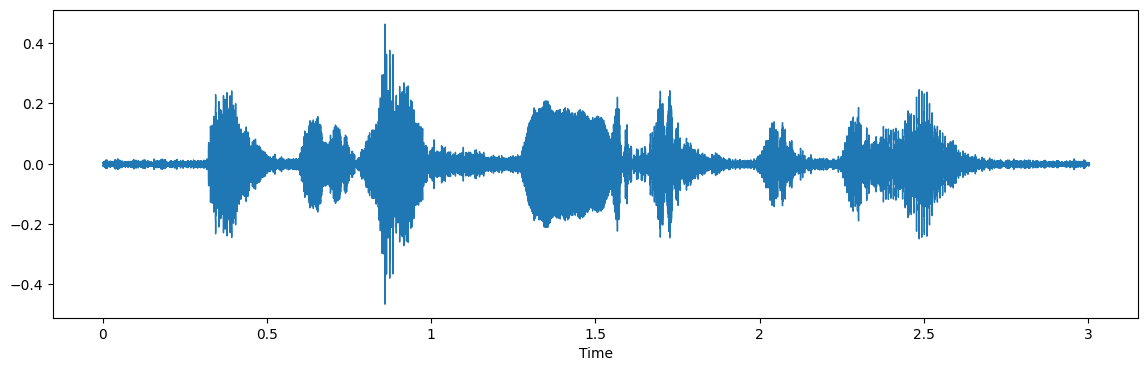

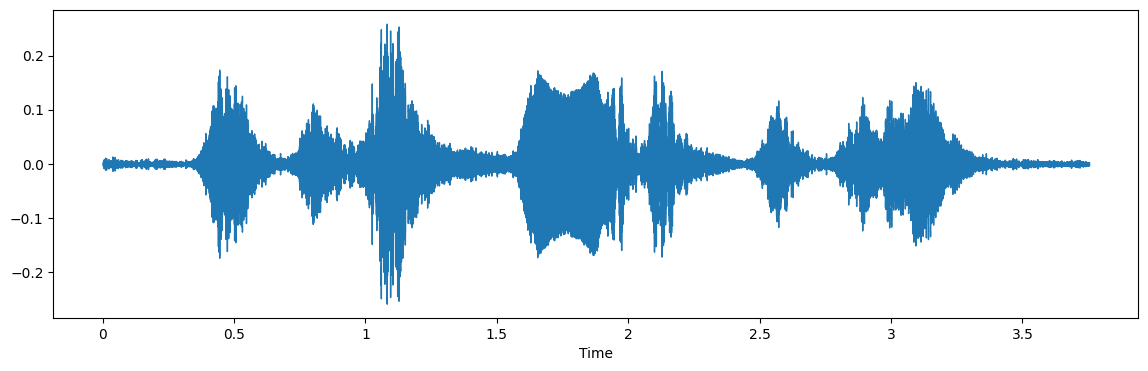

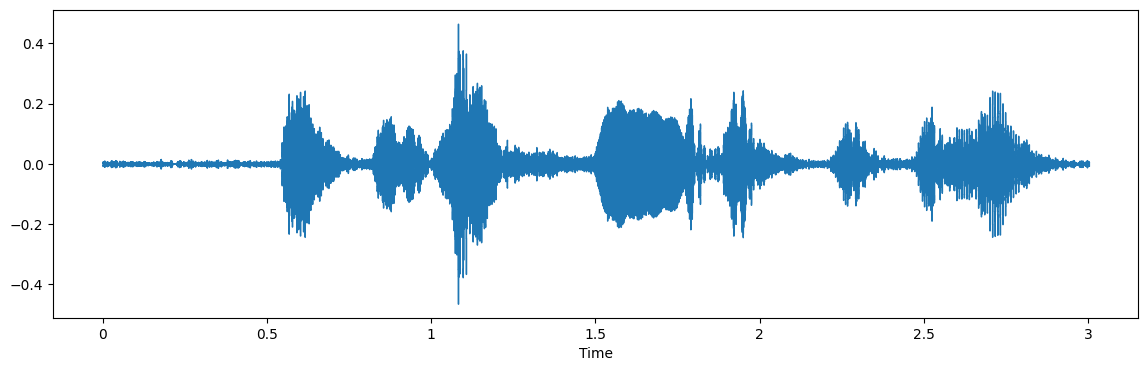

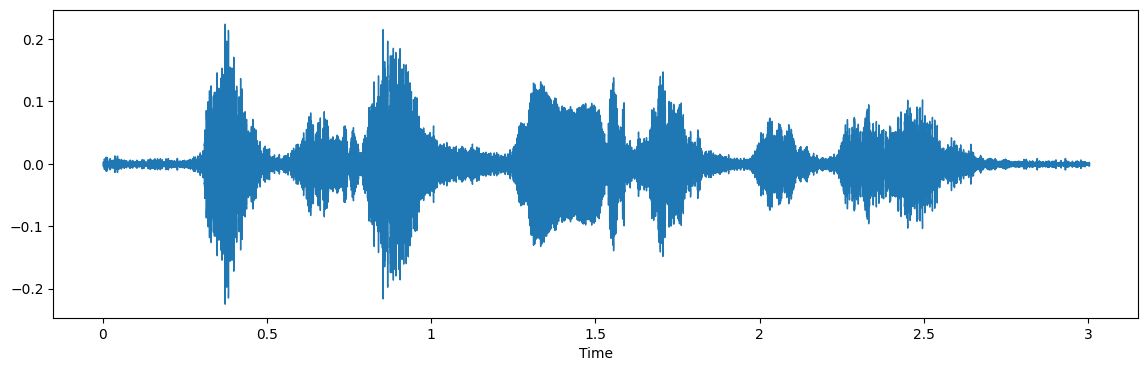

In [2]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, sr=None, rate=0.8):
    """
    Time-stretch audio. Prefer librosa.effects.time_stretch; if its signature
    doesn't match, try keyword call or fallback to resampling.
    - data: 1D np.ndarray
    - sr: sampling rate (required for resample fallback)
    - rate <1 slows down, >1 speeds up (same semantics as librosa.time_stretch)
    """
    try:
        # normal call (most versions)
        return librosa.effects.time_stretch(data, rate)
    except TypeError:
        try:
            # try keyword style if positional fails
            return librosa.effects.time_stretch(y=data, rate=rate)
        except Exception:
            # fallback: simple resample to approximate time-stretch (requires sr)
            if sr is None:
                raise RuntimeError("sr required for resample fallback")
            target_sr = int(sr * rate)
            # resample to change speed: faster if target_sr > sr (approximate)
            return librosa.resample(data, orig_sr=sr, target_sr=target_sr)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    """
    Robust wrapper around librosa pitch-shifting.
    - Tries common signatures: librosa.effects.pitch_shift(y, sr, n_steps)
      and librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps).
    - Falls back to librosa.pitch_shift if present.
    - Final fallback: resample to approximate pitch shift (changes duration).
    """
    # Try common positional signature
    try:
        return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)
    except TypeError:
        # Try keyword-style signature
        try:
            return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)
        except TypeError:
            # Try top-level function if available
            try:
                return librosa.pitch_shift(data, sampling_rate, pitch_factor)
            except Exception:
                # Approximate pitch shift by resampling:
                # n_steps semitones -> rate = 2^(n_steps/12)
                rate = 2.0 ** (pitch_factor / 12.0)
                target_sr = int(sampling_rate * rate)
                return librosa.resample(data, orig_sr=sampling_rate, target_sr=target_sr)


def display_wave(y, sr):
    """Compatibility wrapper: prefer librosa.display.waveshow, fallback to simple plot."""
    try:
        librosa.display.waveshow(y, sr=sr)
    except AttributeError:
        times = np.arange(len(y)) / sr
        plt.plot(times, y)
        plt.xlabel('Time (s)')

# taking any example and checking for techniques.
path = np.array(data_path.Path)[1]
data, sample_rate = librosa.load(path)

plt.figure(figsize=(14,4))
display_wave(y=data, sr=sample_rate)
Audio(path)

x = noise(data)
plt.figure(figsize=(14,4))
display_wave(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

x = stretch(data)
plt.figure(figsize=(14,4))
display_wave(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

x = shift(data)
plt.figure(figsize=(14,4))
display_wave(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

x = pitch(data, sample_rate)
plt.figure(figsize=(14,4))
display_wave(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)




## Feature Extraction
1. **Zero Crossing Rate**: The rate of sign-changes of the signal during the duration of a particular frame.
2. **Chroma Vector**: A 12-element representation of the spectral energy where the bins represent the 12 equal-tempered pitch classes of western-type music (semitone spacing).
3. **MFCC**: Mel Frequency Cepstral Coefficients form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
4. **Root Mean Square Energy (RMS)**: A measure of the signal's loudness/energy, computed as the square root of the mean of squared amplitude values.
5. **Mel Spectrogram**: A representation of how energy is distributed across different frequencies over time, scaled to match human hearing perception.

In [3]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally
    
    return result

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)
    
    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)
    
    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    
    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically
    
    return result

X, Y = [], []
for path, emotion in zip(data_path.Path, data_path.Emotions):
    if (".wav" not in path.lower()):
        continue

    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

len(X), len(Y), data_path.Path.shape

Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('part_a_features.csv', index=False)
Features.head()

/Users/yangqingwei/Library/CloudStorage/GoogleDrive-yangqingwei@gmail.com/My Drive/SUTD/Term 1/ML/ML Lab/venv/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.100537,0.595252,0.551953,0.520970,0.469345,0.523831,0.499308,0.522859,0.581303,0.584584,...,3.271435e-08,3.422750e-08,3.566362e-08,3.697004e-08,3.813983e-08,3.918440e-08,4.004792e-08,4.072397e-08,4.113441e-08,angry
1,0.188770,0.702634,0.653009,0.621660,0.586225,0.648683,0.592185,0.587744,0.645312,0.623009,...,2.106926e-03,2.120305e-03,2.120369e-03,2.238628e-03,2.131439e-03,2.060499e-03,2.085806e-03,2.226787e-03,2.094774e-03,angry
2,0.104364,0.497752,0.632934,0.569837,0.512982,0.442736,0.501116,0.465970,0.491404,0.574312,...,2.177880e-08,2.235584e-08,2.281330e-08,2.315226e-08,2.343286e-08,2.390607e-08,2.462694e-08,2.047304e-08,6.826785e-09,angry
3,0.098154,0.591645,0.502407,0.504114,0.567158,0.523428,0.473053,0.553259,0.547363,0.501392,...,1.217809e-08,1.196999e-08,1.180585e-08,1.167067e-08,1.156780e-08,1.150207e-08,1.145566e-08,1.143310e-08,1.141606e-08,angry
4,0.230586,0.718503,0.652041,0.661950,0.718169,0.651514,0.544639,0.607490,0.603101,0.562422,...,7.130557e-03,7.743195e-03,7.889706e-03,7.877345e-03,7.370286e-03,6.834584e-03,7.359419e-03,7.561705e-03,7.335249e-03,angry


## Prepare Dataset: Apply Standard Scaler, Train/Test split.

In [4]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values

# As this is a multiclass classification problem onehotencoding our Y.
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

# making our data compatible to model.
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape




((16744, 162, 1), (16744, 6), (5582, 162, 1), (5582, 6))

## Implement Models from ML Course 
SVM, Decision Tree, RandomForest, AdaBoost, Bagging, Gassuian Mixture, K-Nearest Neighbour, Naive Bayes, Logistic Regression

Training set: 16744 samples
Test set: 5582 samples
Features: 162
Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']

MODEL TRAINING AND EVALUATION

Training: Logistic Regression...
  CV Accuracy: 0.4337 (+/- 0.0053)
  Test Accuracy: 0.4382
  Training Time: 2.91s

Training: SVM (Linear)...
  CV Accuracy: 0.4480 (+/- 0.0059)
  Test Accuracy: 0.4540
  Training Time: 97.28s

Training: SVM (RBF)...
  CV Accuracy: 0.4697 (+/- 0.0083)
  Test Accuracy: 0.4740
  Training Time: 58.19s

Training: SVM (Polynomial)...
  CV Accuracy: 0.3519 (+/- 0.0059)
  Test Accuracy: 0.3647
  Training Time: 59.25s

Training: Decision Tree...
  CV Accuracy: 0.3984 (+/- 0.0100)
  Test Accuracy: 0.4362
  Training Time: 12.46s

Training: Random Forest (Bagging)...
  CV Accuracy: 0.5454 (+/- 0.0082)
  Test Accuracy: 0.5650
  Training Time: 59.33s

Training: Bagging Classifier...
  CV Accuracy: 0.5562 (+/- 0.0103)
  Test Accuracy: 0.5871
  Training Time: 393.94s

Training: Naive Bayes (Gaussian)...
  CV Accura

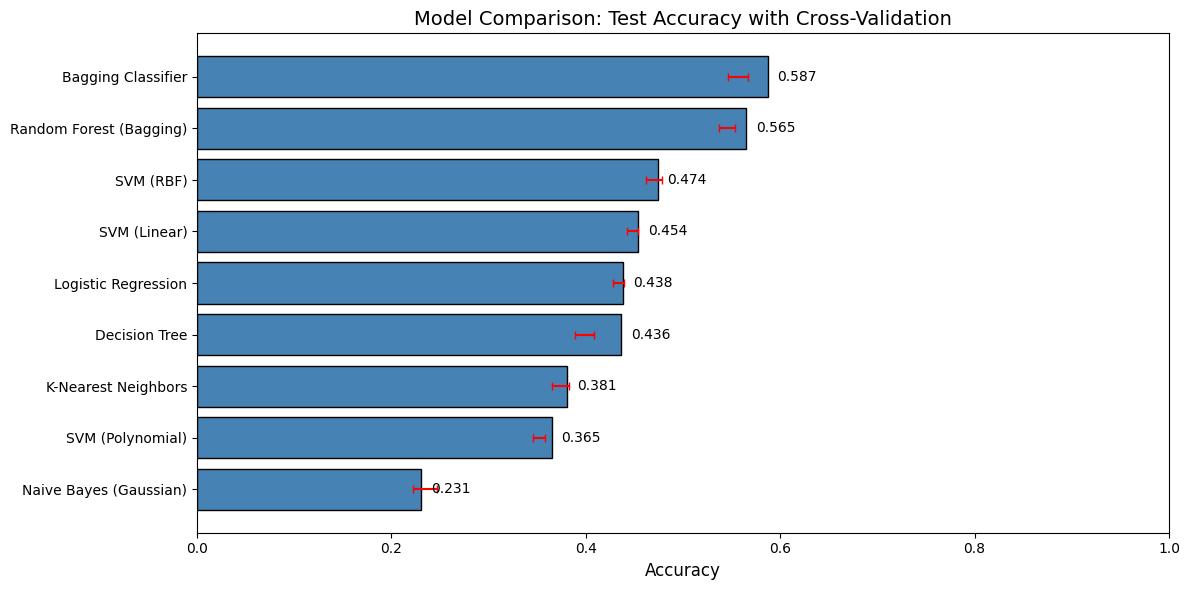


Best Model: Bagging Classifier
Test Accuracy: 0.5871 (58.71%)
Training Time: 393.94s


In [5]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# TRAINING TIME TRACKER 
class TrainingTimeTracker:
    """Track training time and accuracy for each technique"""
    def __init__(self):
        self.records = []
        
    def record(self, technique, accuracy, training_time, category=''):
        self.records.append({
            'Technique': technique,
            'Accuracy': accuracy,
            'Training Time (s)': training_time,
            'Category': category
        })
        
    def get_dataframe(self):
        return pd.DataFrame(self.records)

# Initialize global tracker
tracker = TrainingTimeTracker()

# Data Preparation for sklearn models
# Load features from CSV to ensure consistency
Features = pd.read_csv('part_a_features.csv')
X_2d = Features.iloc[:, :-1].values
y_labels = Features['labels'].values

# Store feature names for later use
feature_names = Features.columns[:-1].tolist()

# Create label encoder for sklearn (not one-hot)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Train/test split (same random_state for reproducibility)
X_train_2d, X_test_2d, y_train_enc, y_test_enc = train_test_split(
    X_2d, y_encoded, test_size=0.25, random_state=0, shuffle=True, stratify=y_encoded
)

# Scale features
scaler_2d = StandardScaler()
X_train_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_scaled = scaler_2d.transform(X_test_2d)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"Features: {X_train_scaled.shape[1]}")
print(f"Classes: {label_encoder.classes_}")

# Define Models from ML Course
models = {
    # Linear Models
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    
    # Support Vector Machines
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'SVM (Polynomial)': SVC(kernel='poly', degree=3, random_state=42),
    
    # Tree-based Models
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    
    # Ensemble Models - Bagging
    'Random Forest (Bagging)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Bagging Classifier': BaggingClassifier(n_estimators=50, random_state=42),
    
    # Ensemble Models - Boosting
    
    # Probabilistic Models
    'Naive Bayes (Gaussian)': GaussianNB(),
    
    # Distance-based (bonus)
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

# Train and Evaluate All Models
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*70)
print("MODEL TRAINING AND EVALUATION")
print("="*70)

for name, model in models.items():
    print(f"\nTraining: {name}...")
    
    # Track training time
    start_time = time.time()
    
    # Cross-validation score on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train_enc, cv=cv, scoring='accuracy')
    
    # Fit on full training set and evaluate on test set
    model.fit(X_train_scaled, y_train_enc)
    y_pred = model.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test_enc, y_pred)
    
    training_time = time.time() - start_time
    
    results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': test_accuracy,
        'Training Time (s)': training_time
    })
    
    # Record in tracker
    tracker.record(name, test_accuracy, training_time, 'Baseline')
    
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Training Time: {training_time:.2f}s")

# Results Summary Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)
results_df['Rank'] = range(1, len(results_df) + 1)
results_df = results_df[['Rank', 'Model', 'CV Mean', 'CV Std', 'Test Accuracy', 'Training Time (s)']]

print("\n" + "="*70)
print("RESULTS SUMMARY (Sorted by Test Accuracy)")
print("="*70)
print(results_df.to_string(index=False))

# Visualization: Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by test accuracy for visualization
results_sorted = results_df.sort_values('Test Accuracy', ascending=True)
y_pos = np.arange(len(results_sorted))

# Create horizontal bar chart
bars = ax.barh(y_pos, results_sorted['Test Accuracy'], color='steelblue', edgecolor='black')

# Add CV error bars
ax.errorbar(results_sorted['CV Mean'], y_pos, 
            xerr=results_sorted['CV Std'], fmt='none', color='red', capsize=3, label='CV Std Dev')

ax.set_yticks(y_pos)
ax.set_yticklabels(results_sorted['Model'])
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Test Accuracy with Cross-Validation', fontsize=14)
ax.set_xlim(0, 1)

# Add accuracy values on bars
for i, (bar, acc) in enumerate(zip(bars, results_sorted['Test Accuracy'])):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{acc:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Best Model Summary
print("\n" + "="*70)
best_model = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy']
best_time = results_df.iloc[0]['Training Time (s)']
print(f"Best Model: {best_model}")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Training Time: {best_time:.2f}s")
print("="*70)




## Detailed Evaluation: Confusion Matrices & Classification Reports

DETAILED CLASSIFICATION REPORTS FOR TOP 4 MODELS

Model: Bagging Classifier
              precision    recall  f1-score   support

       angry       0.66      0.76      0.71       953
     disgust       0.55      0.50      0.52       953
        fear       0.65      0.41      0.50       953
       happy       0.55      0.55      0.55       954
     neutral       0.53      0.58      0.55       815
         sad       0.59      0.72      0.65       954

    accuracy                           0.59      5582
   macro avg       0.59      0.59      0.58      5582
weighted avg       0.59      0.59      0.58      5582


Model: Random Forest (Bagging)
              precision    recall  f1-score   support

       angry       0.65      0.77      0.71       953
     disgust       0.53      0.44      0.48       953
        fear       0.65      0.33      0.44       953
       happy       0.53      0.54      0.53       954
     neutral       0.51      0.59      0.55       815
         sad       0.55 

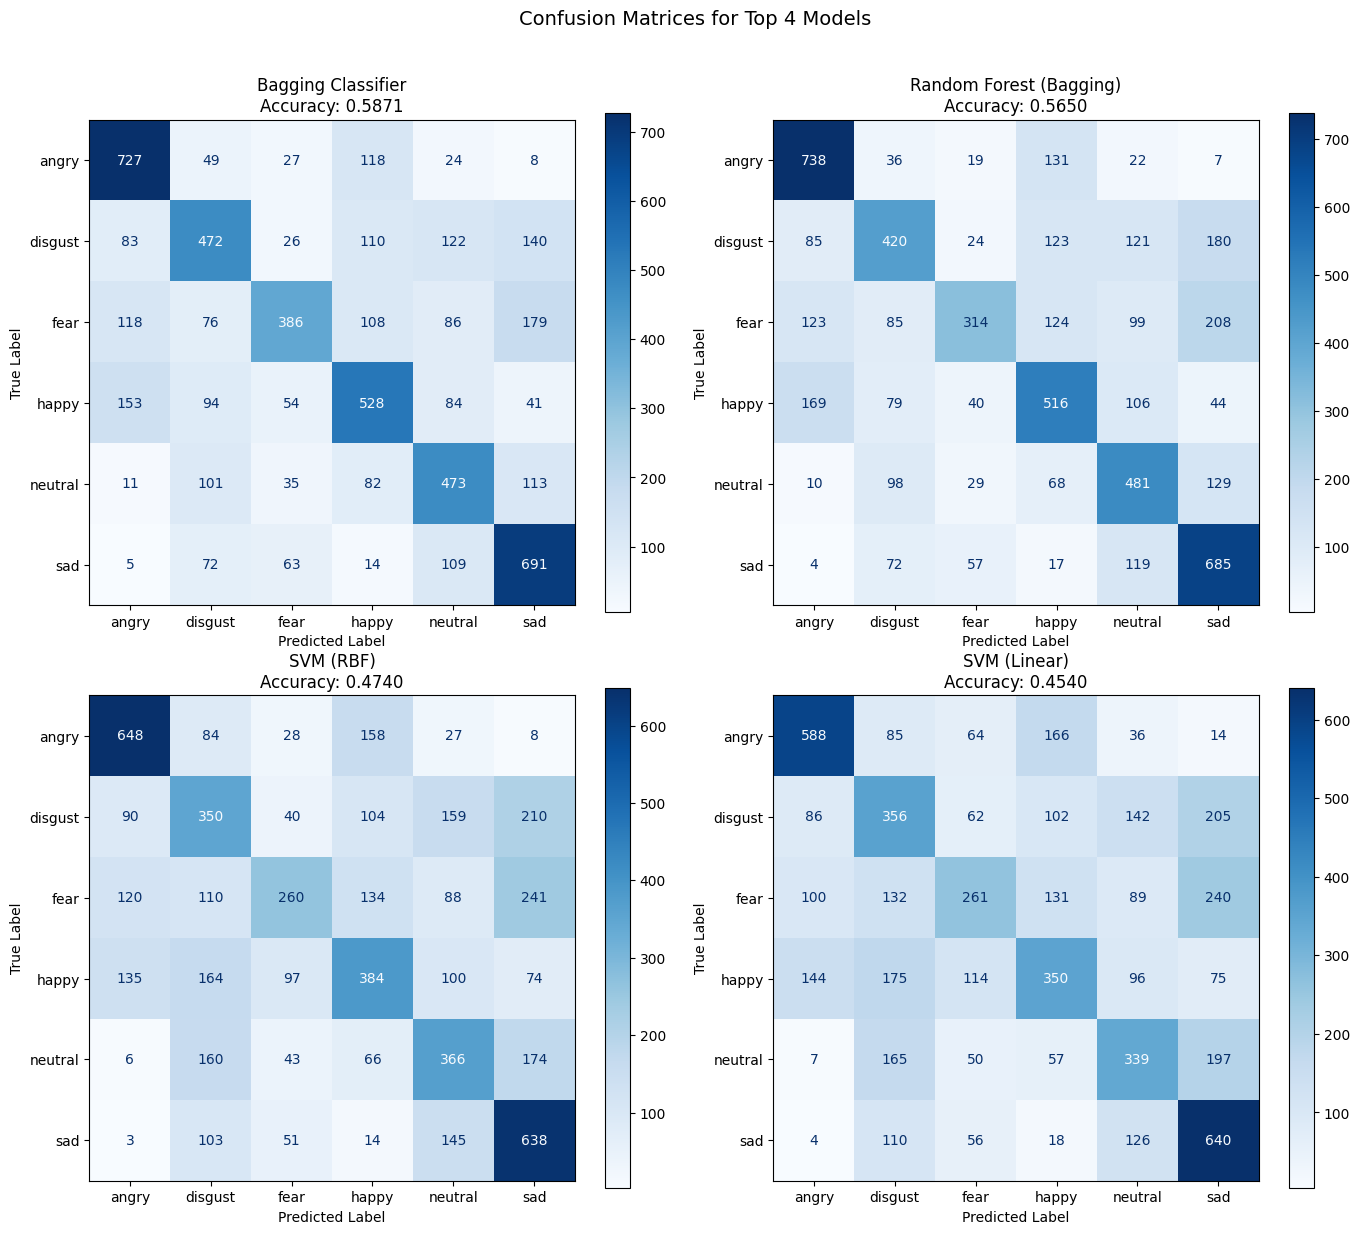


PER-EMOTION ACCURACY ANALYSIS
angry     : 0.7629 (76.3%) - 953 samples
disgust   : 0.4953 (49.5%) - 953 samples
fear      : 0.4050 (40.5%) - 953 samples
happy     : 0.5535 (55.3%) - 954 samples
neutral   : 0.5804 (58.0%) - 815 samples
sad       : 0.7243 (72.4%) - 954 samples


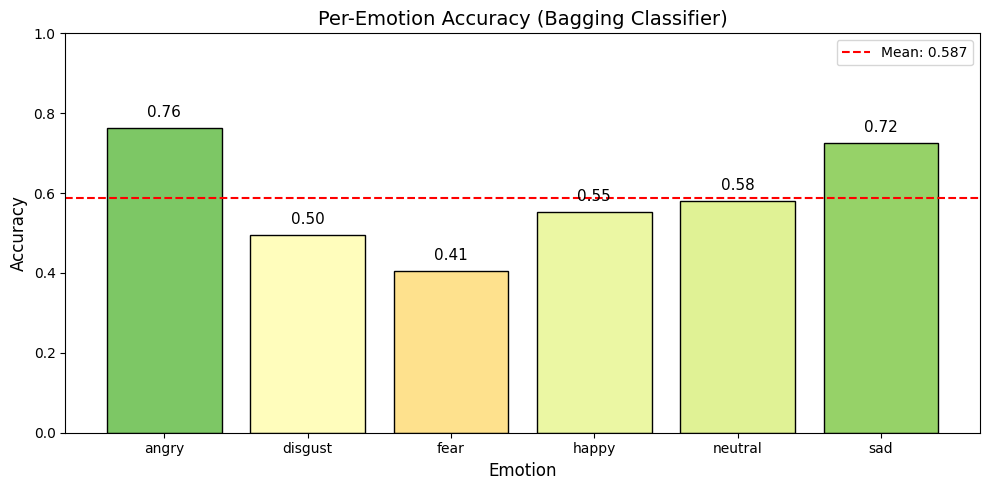


MOST CONFUSED EMOTION PAIRS

Emotion pairs with >5% confusion rate:
  fear       → sad       : 18.8% (179 samples)
  happy      → angry     : 16.0% (153 samples)
  disgust    → sad       : 14.7% (140 samples)
  neutral    → sad       : 13.9% (113 samples)
  disgust    → neutral   : 12.8% (122 samples)
  neutral    → disgust   : 12.4% (101 samples)
  angry      → happy     : 12.4% (118 samples)
  fear       → angry     : 12.4% (118 samples)
  disgust    → happy     : 11.5% (110 samples)
  sad        → neutral   : 11.4% (109 samples)
  fear       → happy     : 11.3% (108 samples)
  neutral    → happy     : 10.1% (82 samples)
  happy      → disgust   : 9.9% (94 samples)
  fear       → neutral   : 9.0% (86 samples)
  happy      → neutral   : 8.8% (84 samples)
  disgust    → angry     : 8.7% (83 samples)
  fear       → disgust   : 8.0% (76 samples)
  sad        → disgust   : 7.5% (72 samples)
  sad        → fear      : 6.6% (63 samples)
  happy      → fear      : 5.7% (54 samples)
  angry 

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

# Select top 4 models for detailed analysis
top_models = results_df.head(4)['Model'].tolist()
emotion_names = label_encoder.classes_

# Re-train and get predictions for top models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

print("="*70)
print("DETAILED CLASSIFICATION REPORTS FOR TOP 4 MODELS")
print("="*70)

for idx, model_name in enumerate(top_models):
    # Get the model and retrain
    model = models[model_name]
    model.fit(X_train_scaled, y_train_enc)
    y_pred = model.predict(X_test_scaled)
    
    # Print classification report
    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")
    print(classification_report(y_test_enc, y_pred, target_names=emotion_names))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test_enc, y_pred):.4f}', fontsize=12)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.suptitle('Confusion Matrices for Top 4 Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Per-Emotion Accuracy Analysis
print("\n" + "="*70)
print("PER-EMOTION ACCURACY ANALYSIS")
print("="*70)

# Use the best model for detailed per-emotion analysis
best_model = models[results_df.iloc[0]['Model']]
best_model.fit(X_train_scaled, y_train_enc)
y_pred_best = best_model.predict(X_test_scaled)

per_emotion_acc = {}
for i, emotion in enumerate(emotion_names):
    mask = y_test_enc == i
    if mask.sum() > 0:
        acc = (y_pred_best[mask] == y_test_enc[mask]).mean()
        per_emotion_acc[emotion] = acc
        print(f"{emotion:10s}: {acc:.4f} ({acc*100:.1f}%) - {mask.sum()} samples")

# Visualize per-emotion accuracy
fig, ax = plt.subplots(figsize=(10, 5))
emotions = list(per_emotion_acc.keys())
accuracies = list(per_emotion_acc.values())

colors = plt.cm.RdYlGn([a for a in accuracies])  # Color by accuracy
bars = ax.bar(emotions, accuracies, color=colors, edgecolor='black')

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Emotion', fontsize=12)
ax.set_title(f'Per-Emotion Accuracy ({results_df.iloc[0]["Model"]})', fontsize=14)
ax.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f'Mean: {np.mean(accuracies):.3f}')
ax.legend()

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Confusion Analysis: Most Confused Emotion Pairs
print("\n" + "="*70)
print("MOST CONFUSED EMOTION PAIRS")
print("="*70)

cm_best = confusion_matrix(y_test_enc, y_pred_best)
# Normalize confusion matrix
cm_normalized = cm_best.astype('float') / cm_best.sum(axis=1)[:, np.newaxis]

# Find most confused pairs (off-diagonal elements)
confusion_pairs = []
for i in range(len(emotion_names)):
    for j in range(len(emotion_names)):
        if i != j and cm_normalized[i, j] > 0.05:  # > 5% confusion
            confusion_pairs.append({
                'True': emotion_names[i],
                'Predicted': emotion_names[j],
                'Rate': cm_normalized[i, j],
                'Count': cm_best[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs)
if not confusion_df.empty:
    confusion_df = confusion_df.sort_values('Rate', ascending=False)
    print("\nEmotion pairs with >5% confusion rate:")
    for _, row in confusion_df.iterrows():
        print(f"  {row['True']:10s} → {row['Predicted']:10s}: {row['Rate']*100:.1f}% ({row['Count']} samples)")
else:
    print("No significant confusion pairs found (all < 5%)")




## Test Additional Model - Gaussian Mixture Model per class
GMM is typically used for unsupervised clustering, but can be adapted for classification by fitting one GMM per class and using likelihood for prediction

GMM-BASED CLASSIFIER EXPERIMENTS
GMM (n=2, diag): 0.3250
GMM (n=3, diag): 0.3196
GMM (n=5, diag): 0.3386
GMM (n=3, full): 0.3882

Best GMM Config: GMM (n=3, full) with 0.3882

FEATURE IMPORTANCE ANALYSIS (Random Forest)

Feature Group Importance:
  Mel Spectrogram     : 0.8100 (81.0%)
  MFCC                : 0.1091 (10.9%)
  Chroma              : 0.0668 (6.7%)
  RMS                 : 0.0091 (0.9%)
  ZCR                 : 0.0050 (0.5%)


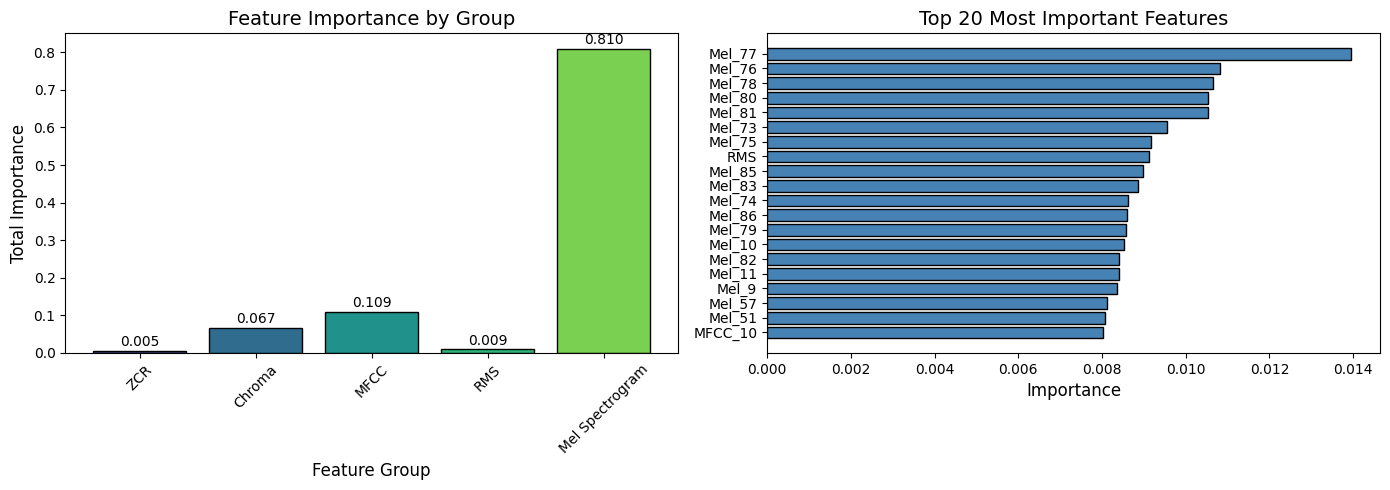


Top 10 Most Important Individual Features:
  Mel_77         : 0.0139
  Mel_76         : 0.0108
  Mel_78         : 0.0107
  Mel_80         : 0.0105
  Mel_81         : 0.0105
  Mel_73         : 0.0096
  Mel_75         : 0.0092
  RMS            : 0.0091
  Mel_85         : 0.0090
  Mel_83         : 0.0089


In [7]:
from sklearn.mixture import GaussianMixture

class GMMClassifier:
    """
    GMM-based classifier: Fits a separate GMM for each class and predicts
    based on which class's GMM assigns highest likelihood to a sample.
    """
    def __init__(self, n_components=3, covariance_type='diag'):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.gmms = {}
        self.classes_ = None
        self.class_priors_ = None
        
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.class_priors_ = {}
        
        for c in self.classes_:
            X_c = X[y == c]
            self.class_priors_[c] = len(X_c) / len(X)
            
            # Fit GMM for this class
            gmm = GaussianMixture(
                n_components=min(self.n_components, len(X_c)),
                covariance_type=self.covariance_type,
                random_state=42,
                max_iter=200
            )
            gmm.fit(X_c)
            self.gmms[c] = gmm
        return self
    
    def predict(self, X):
        # Compute log-likelihood for each class
        log_likelihoods = np.zeros((len(X), len(self.classes_)))
        
        for i, c in enumerate(self.classes_):
            log_likelihoods[:, i] = self.gmms[c].score_samples(X) + np.log(self.class_priors_[c])
        
        # Predict class with highest log-likelihood
        return self.classes_[np.argmax(log_likelihoods, axis=1)]
    
    def predict_proba(self, X):
        log_likelihoods = np.zeros((len(X), len(self.classes_)))
        
        for i, c in enumerate(self.classes_):
            log_likelihoods[:, i] = self.gmms[c].score_samples(X) + np.log(self.class_priors_[c])
        
        # Convert to probabilities via softmax
        max_ll = np.max(log_likelihoods, axis=1, keepdims=True)
        exp_ll = np.exp(log_likelihoods - max_ll)
        return exp_ll / exp_ll.sum(axis=1, keepdims=True)

# Train GMM Classifier with different configurations
print("="*70)
print("GMM-BASED CLASSIFIER EXPERIMENTS")
print("="*70)

gmm_configs = [
    {'n_components': 2, 'covariance_type': 'diag'},
    {'n_components': 3, 'covariance_type': 'diag'},
    {'n_components': 5, 'covariance_type': 'diag'},
    {'n_components': 3, 'covariance_type': 'full'},
]

gmm_results = []
for config in gmm_configs:
    gmm_clf = GMMClassifier(**config)
    gmm_clf.fit(X_train_scaled, y_train_enc)
    y_pred_gmm = gmm_clf.predict(X_test_scaled)
    acc = accuracy_score(y_test_enc, y_pred_gmm)
    
    config_name = f"GMM (n={config['n_components']}, {config['covariance_type']})"
    gmm_results.append({'Config': config_name, 'Accuracy': acc})
    print(f"{config_name}: {acc:.4f}")

gmm_results_df = pd.DataFrame(gmm_results).sort_values('Accuracy', ascending=False)
print(f"\nBest GMM Config: {gmm_results_df.iloc[0]['Config']} with {gmm_results_df.iloc[0]['Accuracy']:.4f}")

# FEATURE IMPORTANCE ANALYSIS (from Random Forest)
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (Random Forest)")
print("="*70)

# Get feature importances from Random Forest
rf_model = models['Random Forest (Bagging)']
rf_model.fit(X_train_scaled, y_train_enc)
importances = rf_model.feature_importances_

# Create feature names
feature_names = []
feature_names.append('ZCR')
feature_names.extend([f'Chroma_{i}' for i in range(12)])
feature_names.extend([f'MFCC_{i}' for i in range(20)])
feature_names.append('RMS')
feature_names.extend([f'Mel_{i}' for i in range(128)])

# Create dataframe of importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Group by feature type
feature_groups = {
    'ZCR': importances[0:1].sum(),
    'Chroma': importances[1:13].sum(),
    'MFCC': importances[13:33].sum(),
    'RMS': importances[33:34].sum(),
    'Mel Spectrogram': importances[34:162].sum()
}

print("\nFeature Group Importance:")
for group, imp in sorted(feature_groups.items(), key=lambda x: x[1], reverse=True):
    print(f"  {group:20s}: {imp:.4f} ({imp*100:.1f}%)")

# Visualize feature importance by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature group importance
ax1 = axes[0]
groups = list(feature_groups.keys())
group_imps = list(feature_groups.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(groups)))
bars = ax1.bar(groups, group_imps, color=colors, edgecolor='black')
ax1.set_ylabel('Total Importance', fontsize=12)
ax1.set_xlabel('Feature Group', fontsize=12)
ax1.set_title('Feature Importance by Group', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
for bar, imp in zip(bars, group_imps):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{imp:.3f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Top 20 individual features
ax2 = axes[1]
top20 = importance_df.head(20)
ax2.barh(range(20), top20['Importance'].values, color='steelblue', edgecolor='black')
ax2.set_yticks(range(20))
ax2.set_yticklabels(top20['Feature'].values)
ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Top 20 Most Important Features', fontsize=14)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Print top 10 features
print("\nTop 10 Most Important Individual Features:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:15s}: {row['Importance']:.4f}")


## 8. Comprehensive Model Summary for ALL Models Tested

COMPREHENSIVE SUMMARY: ALL MODELS EMPLOYED

--------------------------------------------------------------------------------
Rank  Model                       Category              CV Acc        Test Acc  
--------------------------------------------------------------------------------
1     Bagging Classifier          Ensemble (Bagging)    0.5562±0.010  0.5871
2     Random Forest (Bagging)     Ensemble (Bagging)    0.5454±0.008  0.5650
3     SVM (RBF)                   SVM                   0.4697±0.008  0.4740
4     SVM (Linear)                SVM                   0.4480±0.006  0.4540
5     Logistic Regression         Linear                0.4337±0.005  0.4382
6     Decision Tree               Tree-based            0.3984±0.010  0.4362
7     GMM Classifier (Best)       Probabilistic         0.3292±0.007  0.3882
8     K-Nearest Neighbors         Distance-based        0.3742±0.009  0.3809
9     SVM (Polynomial)            SVM                   0.3519±0.006  0.3647
10    Naive Bayes (G

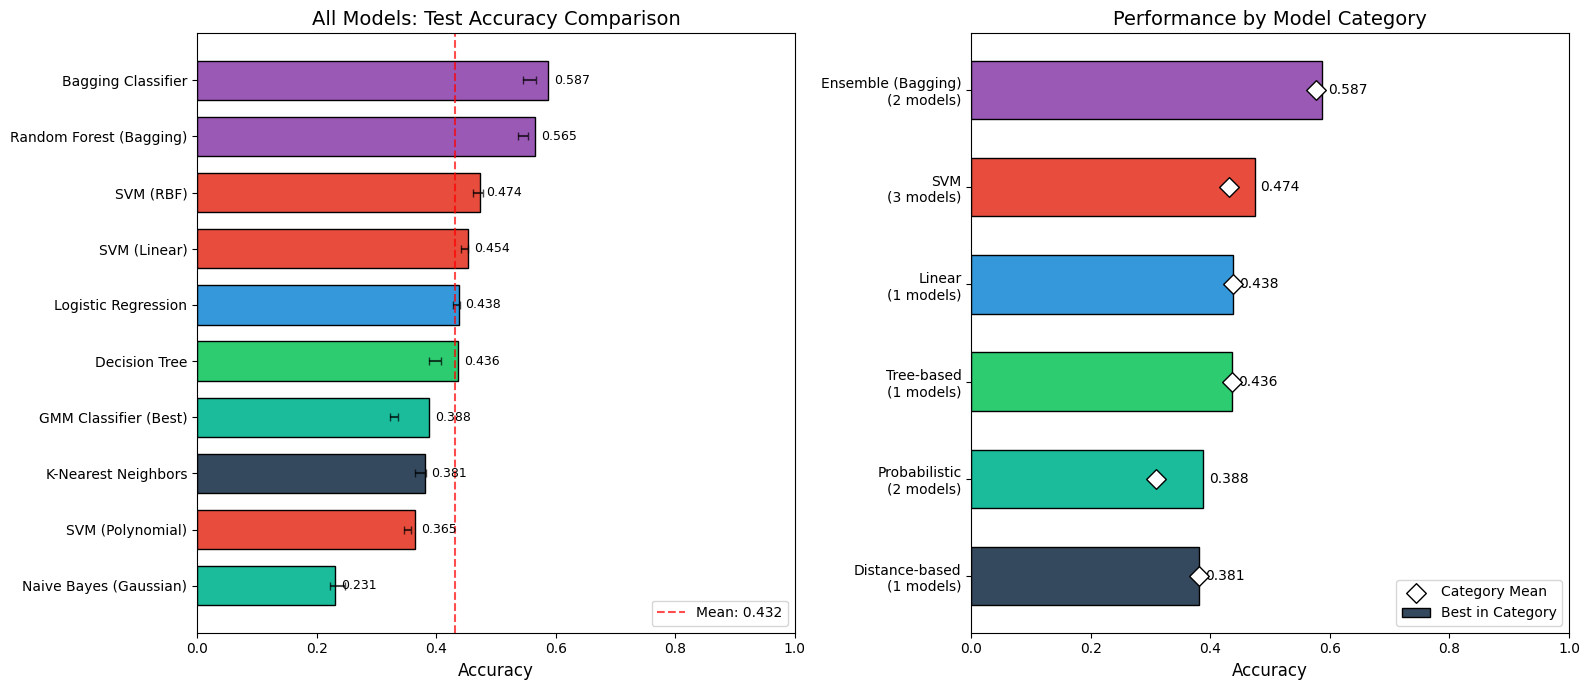


PERFORMANCE BY MODEL CATEGORY

Category                 Models  Mean Acc    Best Acc    Best Model
--------------------------------------------------------------------------------
Ensemble (Bagging)       2       0.5760      0.5871      Bagging Classifier
SVM                      3       0.4309      0.4740      SVM (RBF)
Linear                   1       0.4382      0.4382      Logistic Regression
Tree-based               1       0.4362      0.4362      Decision Tree
Probabilistic            2       0.3095      0.3882      GMM Classifier (Best)
Distance-based           1       0.3809      0.3809      K-Nearest Neighbors

Summary exported to 'part_a_model_comparison_summary.csv'

FINAL VERDICT

Best Performing Model: Bagging Classifier
   - Test Accuracy: 58.71%
   - CV Accuracy: 55.62% (+/-1.03%)
   - Category: Ensemble (Bagging)

Runner-up: Random Forest (Bagging)
   - Test Accuracy: 56.50%
   - Gap from best: 2.20%



In [8]:
def categorize_model(name):
    if 'Logistic' in name:
        return 'Linear'
    elif 'SVM' in name:
        return 'SVM'
    elif 'Decision Tree' in name:
        return 'Tree-based'
    elif 'Random Forest' in name or 'Bagging' in name:
        return 'Ensemble (Bagging)'
    elif 'AdaBoost' in name:
        return 'Ensemble (Boosting)'
    elif 'Naive Bayes' in name:
        return 'Probabilistic'
    elif 'GMM' in name:
        return 'Probabilistic'
    elif 'Neighbor' in name:
        return 'Distance-based'
    return 'Other'

print("="*80)
print("COMPREHENSIVE SUMMARY: ALL MODELS EMPLOYED")
print("="*80)

# Combine all results: sklearn models + GMM variants
all_results = []
for _, row in results_df.iterrows():
    all_results.append({
        'Model': row['Model'],
        'Category': categorize_model(row['Model']),
        'CV Mean': row['CV Mean'],
        'CV Std': row['CV Std'],
        'Test Accuracy': row['Test Accuracy']
    })

# Add best GMM result with cross-validation
gmm_cv_scores = []
for train_idx, val_idx in cv.split(X_train_scaled, y_train_enc):
    gmm_temp = GMMClassifier(n_components=3, covariance_type='diag')
    gmm_temp.fit(X_train_scaled[train_idx], y_train_enc[train_idx])
    y_val_pred = gmm_temp.predict(X_train_scaled[val_idx])
    gmm_cv_scores.append(accuracy_score(y_train_enc[val_idx], y_val_pred))

gmm_cv_scores = np.array(gmm_cv_scores)
gmm_test_acc = gmm_results_df.iloc[0]['Accuracy']

all_results.append({
    'Model': 'GMM Classifier (Best)',
    'Category': 'Probabilistic',
    'CV Mean': gmm_cv_scores.mean(),
    'CV Std': gmm_cv_scores.std(),
    'Test Accuracy': gmm_test_acc
})

# Create final summary dataframe
summary_df = pd.DataFrame(all_results)
summary_df = summary_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
summary_df.insert(0, 'Rank', range(1, len(summary_df) + 1))

# Display summary table
print("\n" + "-"*80)
print(f"{'Rank':<6}{'Model':<28}{'Category':<22}{'CV Acc':<14}{'Test Acc':<10}")
print("-"*80)
for _, row in summary_df.iterrows():
    print(f"{row['Rank']:<6}{row['Model']:<28}{row['Category']:<22}{row['CV Mean']:.4f}±{row['CV Std']:.3f}  {row['Test Accuracy']:.4f}")
print("-"*80)

# Calculate statistics
print(f"\nTotal Models Evaluated: {len(summary_df)}")
print(f"Best Model: {summary_df.iloc[0]['Model']} ({summary_df.iloc[0]['Test Accuracy']*100:.2f}%)")
print(f"Worst Model: {summary_df.iloc[-1]['Model']} ({summary_df.iloc[-1]['Test Accuracy']*100:.2f}%)")
print(f"Average Accuracy: {summary_df['Test Accuracy'].mean()*100:.2f}%")
print(f"Accuracy Std Dev: {summary_df['Test Accuracy'].std()*100:.2f}%")

# Final Visualization: All Models Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Horizontal bar chart of all models
ax1 = axes[0]
colors_map = {
    'Linear': '#3498db',
    'SVM': '#e74c3c', 
    'Tree-based': '#2ecc71',
    'Ensemble (Bagging)': '#9b59b6',
    'Ensemble (Boosting)': '#f39c12',
    'Probabilistic': '#1abc9c',
    'Distance-based': '#34495e'
}

summary_sorted = summary_df.sort_values('Test Accuracy', ascending=True)
y_pos = np.arange(len(summary_sorted))
bar_colors = [colors_map.get(cat, '#95a5a6') for cat in summary_sorted['Category']]

bars = ax1.barh(y_pos, summary_sorted['Test Accuracy'], color=bar_colors, edgecolor='black', height=0.7)
ax1.errorbar(summary_sorted['CV Mean'], y_pos, xerr=summary_sorted['CV Std'], 
             fmt='none', color='black', capsize=3, alpha=0.7)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(summary_sorted['Model'], fontsize=10)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('All Models: Test Accuracy Comparison', fontsize=14)
ax1.set_xlim(0, 1)
ax1.axvline(x=summary_df['Test Accuracy'].mean(), color='red', linestyle='--', 
            label=f'Mean: {summary_df["Test Accuracy"].mean():.3f}', alpha=0.7)
ax1.legend(loc='lower right')

# Add accuracy values
for bar, acc in zip(bars, summary_sorted['Test Accuracy']):
    ax1.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{acc:.3f}', va='center', fontsize=9)

# Plot 2: Category comparison (grouped)
ax2 = axes[1]
category_stats = summary_df.groupby('Category').agg({
    'Test Accuracy': ['mean', 'max', 'count']
}).round(4)
category_stats.columns = ['Mean Acc', 'Best Acc', 'Count']
category_stats = category_stats.sort_values('Best Acc', ascending=True)

y_pos2 = np.arange(len(category_stats))
cat_colors = [colors_map.get(cat, '#95a5a6') for cat in category_stats.index]

# Plot best accuracy per category
bars2 = ax2.barh(y_pos2, category_stats['Best Acc'], color=cat_colors, 
                  edgecolor='black', height=0.6, label='Best in Category')
# Overlay mean as marker
ax2.scatter(category_stats['Mean Acc'], y_pos2, color='white', edgecolor='black', 
            s=100, zorder=5, marker='D', label='Category Mean')

ax2.set_yticks(y_pos2)
ax2.set_yticklabels([f"{cat}\n({int(cnt)} models)" for cat, cnt in 
                     zip(category_stats.index, category_stats['Count'])], fontsize=10)
ax2.set_xlabel('Accuracy', fontsize=12)
ax2.set_title('Performance by Model Category', fontsize=14)
ax2.set_xlim(0, 1)
ax2.legend(loc='lower right')

# Add values
for i, (best, mean) in enumerate(zip(category_stats['Best Acc'], category_stats['Mean Acc'])):
    ax2.text(best + 0.01, i, f'{best:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Summary Statistics by Category
print("\n" + "="*80)
print("PERFORMANCE BY MODEL CATEGORY")
print("="*80)
print(f"\n{'Category':<25}{'Models':<8}{'Mean Acc':<12}{'Best Acc':<12}{'Best Model'}")
print("-"*80)

for category in summary_df['Category'].unique():
    cat_df = summary_df[summary_df['Category'] == category]
    best_in_cat = cat_df.iloc[0]
    print(f"{category:<25}{len(cat_df):<8}{cat_df['Test Accuracy'].mean():.4f}      {cat_df['Test Accuracy'].max():.4f}      {best_in_cat['Model']}")

# Export Summary to CSV
summary_df.to_csv('part_a_model_comparison_summary.csv', index=False)
print(f"\nSummary exported to 'part_a_model_comparison_summary.csv'")

# Final verdict
print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)
best = summary_df.iloc[0]
second = summary_df.iloc[1]
print(f"""
Best Performing Model: {best['Model']}
   - Test Accuracy: {best['Test Accuracy']*100:.2f}%
   - CV Accuracy: {best['CV Mean']*100:.2f}% (+/-{best['CV Std']*100:.2f}%)
   - Category: {best['Category']}

Runner-up: {second['Model']}
   - Test Accuracy: {second['Test Accuracy']*100:.2f}%
   - Gap from best: {(best['Test Accuracy'] - second['Test Accuracy'])*100:.2f}%
""")

In [9]:
MODELS_TO_RUN = [
    'svm',      # Support Vector Machine
    'rf',       # Random Forest
    'lr',       # Logistic Regression
    'nb',       # Naive Bayes (ensemble only)
    'knn',      # K-Nearest Neighbors (ensemble only)
    'ada',      # AdaBoost (ensemble only)
]

# Ensemble methods to run
ENSEMBLE_METHODS = [
    'voting',   # Hard & Soft Voting
    'stacking', # Stacking Classifier
    'weighted', # Custom Weighted Voting
]

print("="*80)
print("MODEL CONFIGURATION")
print("="*80)
print(f"Models to run: {MODELS_TO_RUN}")
print(f"Ensemble methods: {ENSEMBLE_METHODS}")


MODEL CONFIGURATION
Models to run: ['svm', 'rf', 'lr', 'nb', 'knn', 'ada']
Ensemble methods: ['voting', 'stacking', 'weighted']


# Hyperparameter Tuning

In this section, we perform hyperparameter tuning for all nine baseline classifiers to see if we can further improve their accuracy. We use `GridSearchCV` with stratified 3-fold cross-validation to search over small, interpretable grids for:

- Logistic Regression
- SVM (Linear)
- SVM (RBF)
- SVM (Polynomial)
- Decision Tree
- Random Forest (Bagging)
- Bagging Classifier
- K-Nearest Neighbors
- Naive Bayes (Gaussian)

We then compare the tuned test accuracy against the original baseline results.


Checking for and cleaning NaN/Inf values in feature data...
Data cleaned (NaN/Inf -> 0, clipped to ±100.0).
HYPERPARAMETER TUNING WITH GridSearchCV

Tuning: Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best CV Score: 0.4357
  Tuned Test Accuracy: 0.4387
  Best Parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
  Tuning Time: 3.25s

Tuning: SVM (Linear)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best CV Score: 0.4471
  Tuned Test Accuracy: 0.4540
  Best Parameters: {'C': 1.0}
  Tuning Time: 388.48s

Tuning: SVM (RBF)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  Best CV Score: 0.5306
  Tuned Test Accuracy: 0.5616
  Best Parameters: {'C': 50, 'gamma': 'auto'}
  Tuning Time: 173.66s

Tuning: SVM (Polynomial)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  Best CV Score: 0.4620
  Tuned Test Accuracy: 0.4799
  Best Parameters: {'C': 10.0, 'degree': 2, 'gamma': 'auto'}
  Tuning Time: 264

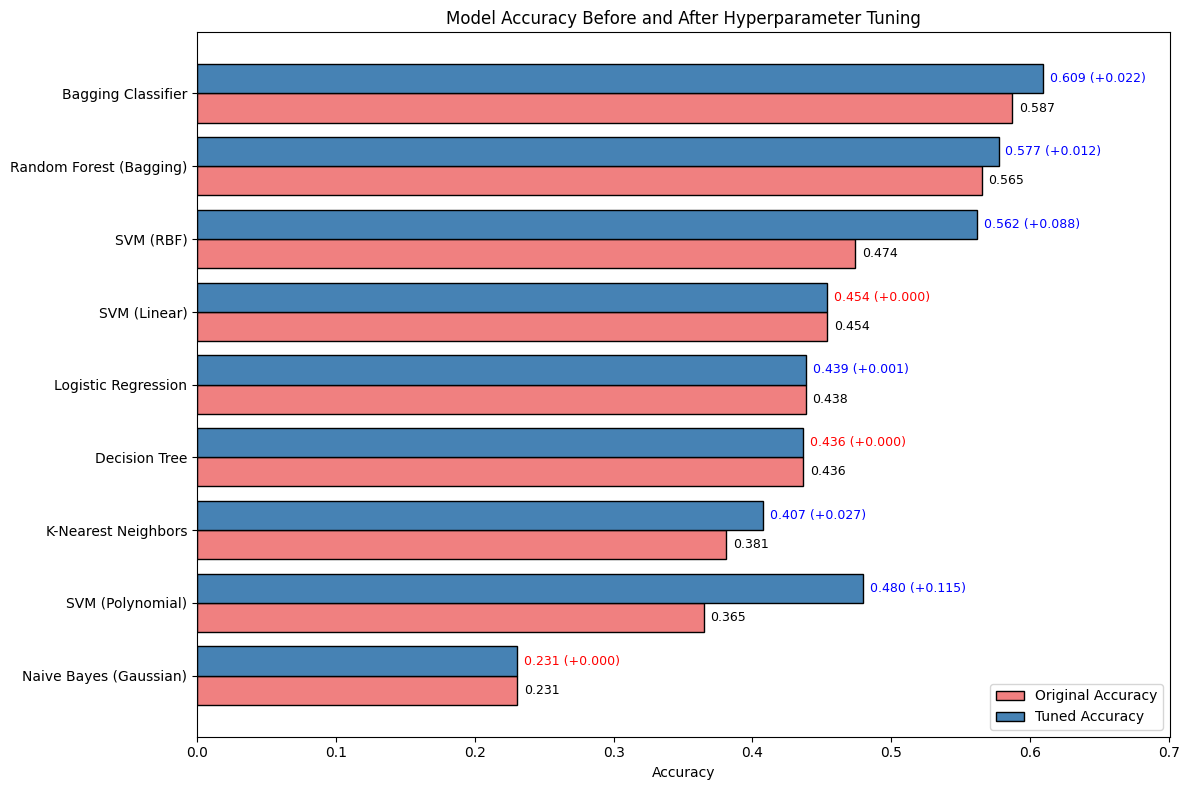

In [10]:
print("Checking for and cleaning NaN/Inf values in feature data...")
if 'X_train_scaled' in locals() and 'X_test_scaled' in locals():
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)
    clip_val = 1e2
    X_train_scaled = np.clip(X_train_scaled, -clip_val, clip_val)
    X_test_scaled = np.clip(X_test_scaled, -clip_val, clip_val)
    print(f'Data cleaned (NaN/Inf -> 0, clipped to ±{clip_val}).')
else:
    raise RuntimeError('Scaled data not loaded. Run baseline training cell first.')

# Import necessary libraries
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define models and parameter grids for tuning
# Here we tune all nine baseline classifiers
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'solver': ['lbfgs'],
        'max_iter': [1000],
    },
    'SVM (Linear)': {
        'C': [0.1, 1.0, 10.0],
    },
    'SVM (RBF)': {
        'C': [1, 10, 50],
        'gamma': ['scale', 'auto'],
    },
    'SVM (Polynomial)': {
        'C': [0.1, 1.0, 10.0],
        'degree': [2, 3],
        'gamma': ['scale', 'auto'],
    },
    'Decision Tree': {
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
    },
    'Random Forest (Bagging)': {
        'n_estimators': [100, 200],
        'max_depth': [20, 30, None],
        'max_features': ['sqrt', 'log2'],
    },
    'Bagging Classifier': {
        'n_estimators': [50, 100, 150],
        'max_samples': [0.5, 0.8, 1.0],
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [5, 7, 9],
        'weights': ['uniform', 'distance'],
    },
    'Naive Bayes (Gaussian)': {
        'var_smoothing': [1e-9, 1e-8, 1e-7],
    },
}

# The models dictionary needs to be re-defined here for GridSearchCV
models_to_tune = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Polynomial)': SVC(kernel='poly', degree=3, probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest (Bagging)': RandomForestClassifier(random_state=42),
    'Bagging Classifier': BaggingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes (Gaussian)': GaussianNB(),
}

tuned_results = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # Using 3 splits for speed

print("="*70)
print("HYPERPARAMETER TUNING WITH GridSearchCV")
print("="*70)

for name, model in models_to_tune.items():
    if name in param_grids:
        print(f"\nTuning: {name}...")
        start_time = time.time()
        
        grid_search = GridSearchCV(model, param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
        grid_search.fit(X_train_scaled, y_train_enc)
        
        # Evaluate on test set with best estimator
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        test_accuracy = accuracy_score(y_test_enc, y_pred)
        
        tuning_time = time.time() - start_time
        
        tuned_results.append({
            'Model': name,
            'Tuned Test Accuracy': test_accuracy,
            'Best Params': grid_search.best_params_,
            'Tuning Time (s)': tuning_time
        })
        
        print(f"  Best CV Score: {grid_search.best_score_:.4f}")
        print(f"  Tuned Test Accuracy: {test_accuracy:.4f}")
        print(f"  Best Parameters: {grid_search.best_params_}")
        print(f"  Tuning Time: {tuning_time:.2f}s")

tuned_results_df = pd.DataFrame(tuned_results)

# Combine with original results for comparison
# Ensure original results_df is available from the notebook's execution context
comparison_df = pd.merge(results_df, tuned_results_df[['Model', 'Tuned Test Accuracy', 'Best Params']], on='Model', how='left')
comparison_df = comparison_df[['Model', 'Test Accuracy', 'Tuned Test Accuracy', 'Best Params']]
comparison_df.rename(columns={'Test Accuracy': 'Original Test Accuracy'}, inplace=True)
comparison_df['Improvement'] = comparison_df['Tuned Test Accuracy'] - comparison_df['Original Test Accuracy']
comparison_df['Improvement'] = comparison_df['Improvement'].apply(lambda x: f"{x:+.4f}" if pd.notnull(x) else None)


print("\n" + "="*70)
print("COMPARISON: ORIGINAL VS. TUNED MODELS")
print("="*70)
print(comparison_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
comparison_sorted = comparison_df.dropna(subset=['Tuned Test Accuracy']).sort_values('Original Test Accuracy')
y_pos = np.arange(len(comparison_sorted))
height = 0.4

bars1 = ax.barh(y_pos - height/2, comparison_sorted['Original Test Accuracy'], height, label='Original Accuracy', color='lightcoral', edgecolor='black')
bars2 = ax.barh(y_pos + height/2, comparison_sorted['Tuned Test Accuracy'], height, label='Tuned Accuracy', color='steelblue', edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_sorted['Model'])
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Before and After Hyperparameter Tuning')
ax.legend()
ax.set_xlim(0, max(comparison_df['Original Test Accuracy'].max(), comparison_df['Tuned Test Accuracy'].dropna().max()) * 1.15)

# Add labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    orig_acc = bar1.get_width()
    tuned_acc = bar2.get_width()
    improvement = tuned_acc - orig_acc

    ax.text(bar1.get_width() + 0.005, bar1.get_y() + bar1.get_height()/2, f'{orig_acc:.3f}', va='center', ha='left', fontsize=9)
    ax.text(bar2.get_width() + 0.005, bar2.get_y() + bar2.get_height()/2, f'{tuned_acc:.3f} (+{improvement:.3f})', va='center', ha='left', fontsize=9, color='blue' if improvement > 0 else 'red')


plt.tight_layout()
plt.show()

# Store results for next part
original_results_with_time = tracker.get_dataframe()
tuned_results_df.to_csv('part_a_tuned_results.csv', index=False)
comparison_df.to_csv('part_a_final_comparison.csv', index=False)


CONFUSION MATRICES FOR TOP 4 BASE MODELS


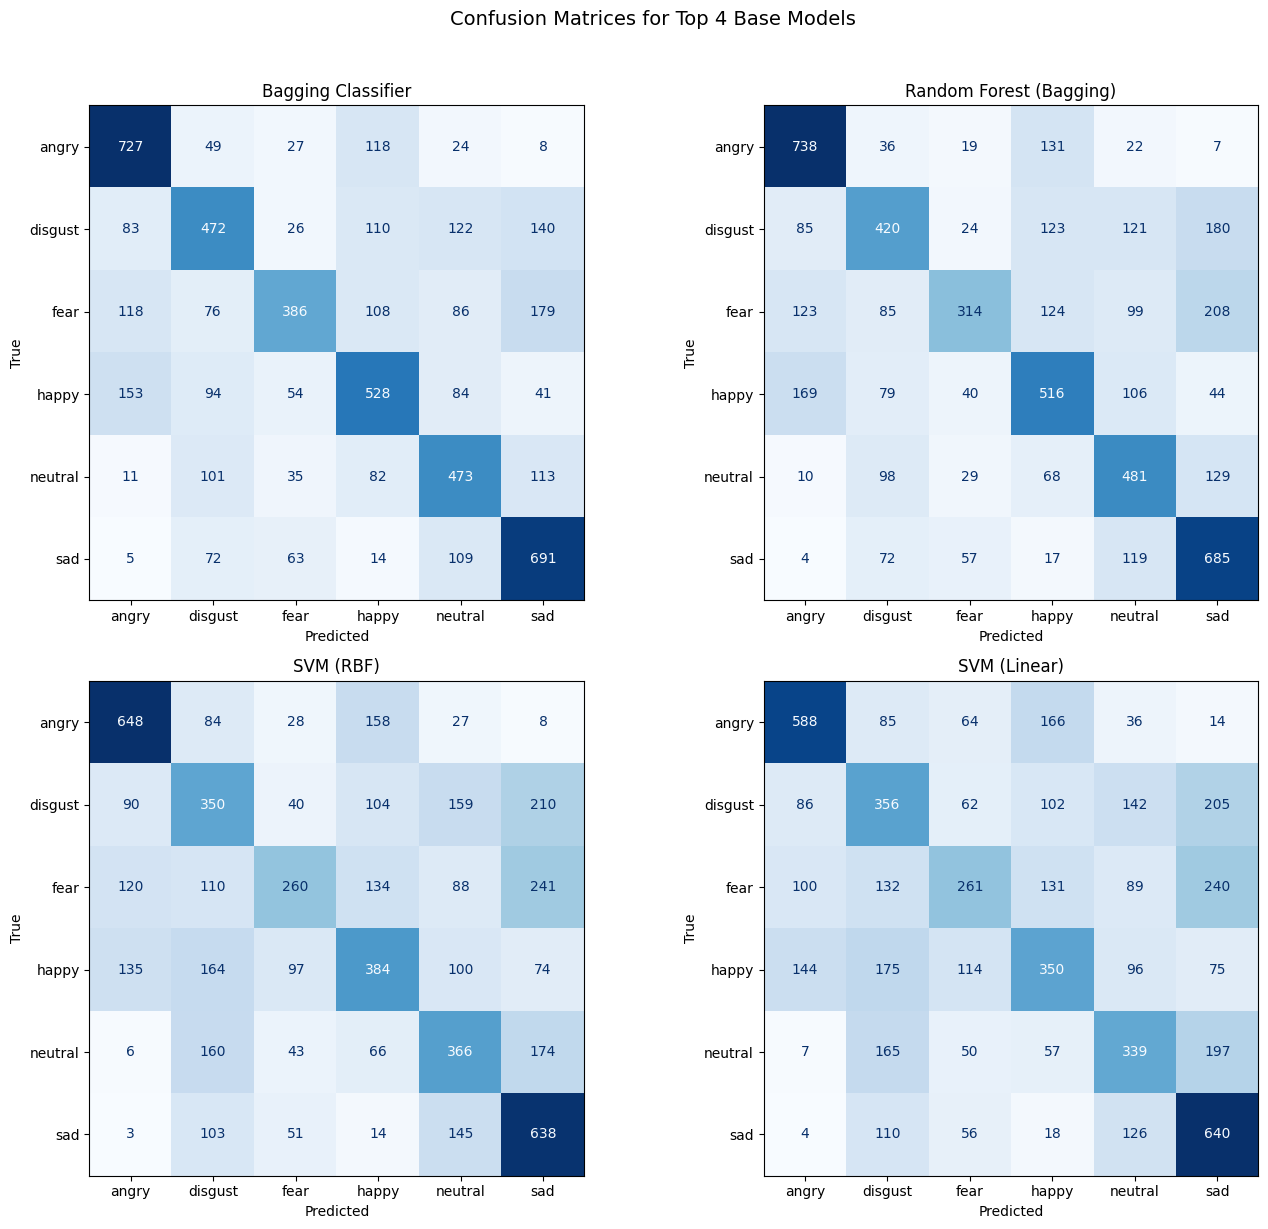

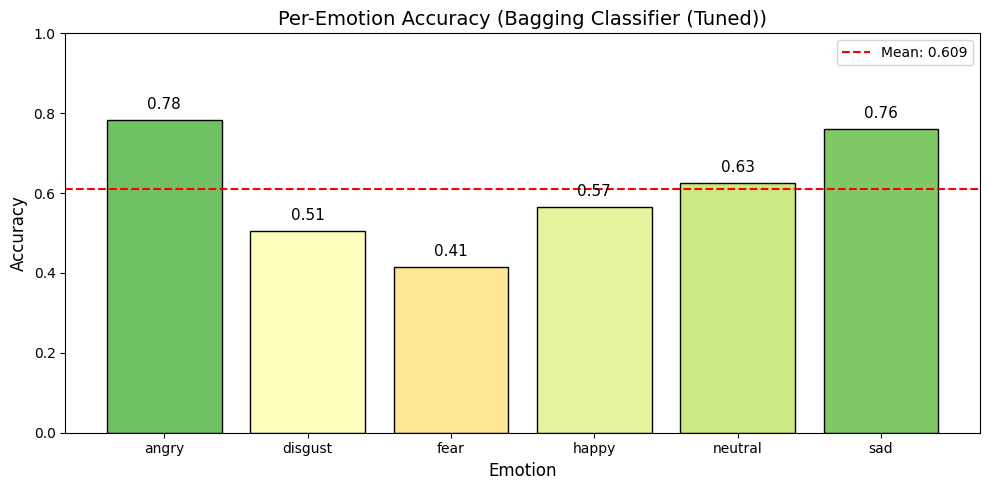

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import BaggingClassifier

top_models_for_cm = results_df.sort_values('Test Accuracy', ascending=False).head(4)['Model'].tolist()
emotion_names = label_encoder.classes_

print("="*70)
print("CONFUSION MATRICES FOR TOP 4 BASE MODELS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, model_name in enumerate(top_models_for_cm):
    model = models[model_name]
    model.fit(X_train_scaled, y_train_enc)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(f"{model_name}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.suptitle('Confusion Matrices for Top 4 Base Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Per-emotion accuracy for Bagging Classifier (tuned if available)
bagging_title_suffix = ""
try:
    bagging_row = tuned_results_df.loc[tuned_results_df['Model'] == 'Bagging Classifier']
    if not bagging_row.empty:
        best_params = bagging_row['Best Params'].iloc[0]
        bagging_model = BaggingClassifier(random_state=42, **best_params)
        bagging_title_suffix = " (Tuned)"
    else:
        bagging_model = models['Bagging Classifier']
except NameError:
    bagging_model = models['Bagging Classifier']

bagging_model.fit(X_train_scaled, y_train_enc)
y_pred_bagging = bagging_model.predict(X_test_scaled)

per_emotion_acc = {}
for i, emotion in enumerate(emotion_names):
    mask = (y_test_enc == i)
    if mask.sum() > 0:
        acc = (y_pred_bagging[mask] == y_test_enc[mask]).mean()
        per_emotion_acc[emotion] = acc

fig, ax = plt.subplots(figsize=(10, 5))
emotions = list(per_emotion_acc.keys())
accuracies = list(per_emotion_acc.values())
colors = plt.cm.RdYlGn(accuracies)
bars = ax.bar(emotions, accuracies, color=colors, edgecolor='black')

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Emotion', fontsize=12)
ax.set_title(f'Per-Emotion Accuracy (Bagging Classifier{bagging_title_suffix})', fontsize=14)
mean_acc = np.mean(accuracies)
ax.axhline(y=mean_acc, color='red', linestyle='--', label=f'Mean: {mean_acc:.3f}')
ax.legend()

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{acc:.2f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()
